# 1.1 文字怎麼變成可還原的編號？


我們要讓程式看到「貓」時猜下一字。先準備一句材料：**貓看狗，狗看貓。** 希望程式既能記錄這些字，又能在猜完後把結果寫回人能讀的文字，所以需要一張雙向對照表。

替每種字安排一個整數，這個數叫 ID，也就是識別編號。本例的約定如下；標點也是句子的一部分，照樣編號。

| 字 | 。 | 狗 | 看 | 貓 | ， |
| --- | --- | --- | --- | --- | --- |
| ID | 0 | 1 | 2 | 3 | 4 |

因此原句可記成 `[3,2,1,4,1,2,3,0]`。兩次「貓」都用 3，兩次「狗」都用 1。ID 像書的索書號，只用來找同一項：3 不表示貓比狗大三倍，也不表示意思更接近哪個字。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

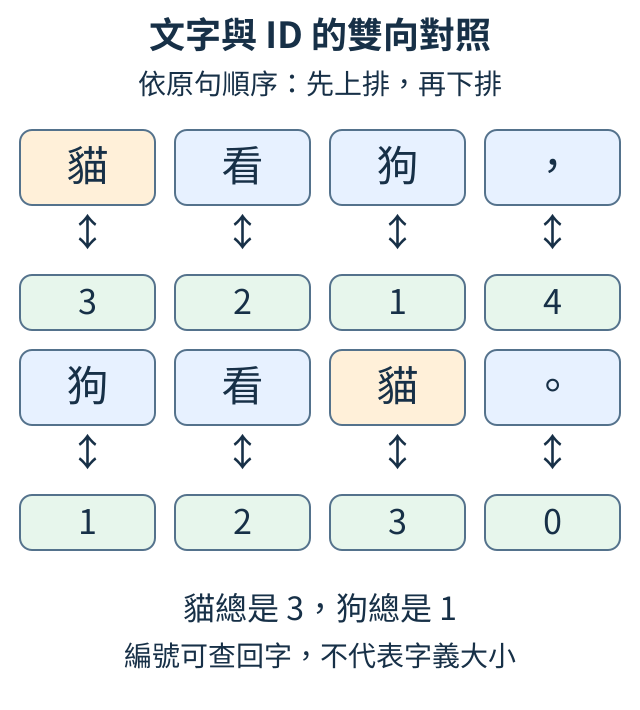

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-01-character-ids.svg")))

圖中的上下兩格是一個字與它的 ID。電腦往下查得到編號，往上查能還原文字；現在還沒有任何猜字能力。

下面讓 Python 建立這張表。包含所有可用字的清單叫**字表**；`set(text)` 去除重複字，`sorted` 再按電腦的文字編碼順序排列。這個順序是約定，不是按字義或筆畫排列。


In [3]:
text = "鳥看狗，狗看鳥。"
chars = sorted(set(text))
to_id = {}
for i, char in enumerate(chars):
    to_id[char] = i
ids = [to_id[char] for char in text]
restored = "".join(chars[i] for i in ids)
print(chars)
print(ids)
print(restored)
assert restored == text

['。', '狗', '看', '鳥', '，']
[3, 2, 1, 4, 1, 2, 3, 0]
鳥看狗，狗看鳥。


`enumerate(chars)` 逐項提供「位置、字」，迴圈將它存入字典 `to_id`。`[to_id[char] for char in text]` 則按原句順序逐字查編號。三行輸出依序是 `['。','狗','看','貓','，']`、`[3,2,1,4,1,2,3,0]` 和原句。

最後的 `chars[i]` 由編號查回字，`"".join(...)` 把字接起來。文字變編號叫**編碼**，編號變文字叫**解碼**；`assert restored == text` 檢查來回後仍是同一句，透過時沒有額外輸出。這個檢查證明記錄可還原，不表示程式懂了貓或狗。

練習把建立字表那行改成 `chars = sorted(set(text), reverse=True)`。先預測 ID 和還原文字各會怎樣，再執行：字表順序與 ID 都改變，但編碼、解碼使用同一張新表，仍能得到原句。

<details>
<summary>補充與重做</summary>

Python 清單、字典與方括號可回看 [W.2](https://birdhackor.github.io/tiny-perceptron-vlm/first-steps.html#W.2)。排序依 Unicode 的字元編碼；本例只處理字表已有的字。若拿同一張表編碼「貓看鳥」，因為沒有「鳥」，會出現 `KeyError`。第 6 章會處理字表涵蓋範圍與更實用的拆字方法。

</details>


In [4]:
assert 'p6_namespace_sentinel' not in globals()
p6_namespace_sentinel = True
assert torch.cuda.is_available() is False
print('p6_fresh_namespace_verified', torch.__version__, torch.tensor([1]).device.type)

p6_fresh_namespace_verified 2.14.1+cpu cpu
